In [11]:
# Import required libraries 
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# This is a numpy function I made for this notebook.
# Basically It will take a random float values between 0 to 1 of size passed.
# Then all the values inside the newly formed array is multplied by 10 and converted to range (1-10) .
# Then we take the ceiling value of this so that it truly is in the range (1-10).
X = np.ceil(np.random.rand(10,2)*10)

In [3]:
X # Look of the new numpy array

array([[ 8., 10.],
       [ 6.,  2.],
       [ 4.,  5.],
       [ 2.,  4.],
       [ 5., 10.],
       [ 9.,  3.],
       [ 8.,  3.],
       [ 6.,  1.],
       [ 5.,  7.],
       [ 6.,  8.]])

In [4]:
# NearestNeighbors basically calcualates the distance for each of the point with other points using the algorithm passed
# and then returns the indices and distances from the Nearest Neighbors (the value is sey by us) from that point 
# (done for each point in the graph).

# Instantiate the model
nnbrs = NearestNeighbors(
    n_neighbors = 3, # The number of neighbors each point should have 
    algorithm = 'ball_tree' # The algorithm used to compute Nearest Neighbors
).fit(X) # Also fitting X during instantiation

In [5]:
distances,indices = nnbrs.kneighbors(X) # Use the kneighbors method and pass the matrix for which we are calculating the nearestneighbors.
# The distances and indices for the nearest k neighbors will be returned

In [6]:
indices # The indices of the nearest neighbor for each point

array([[0, 9, 4],
       [1, 7, 6],
       [2, 8, 3],
       [3, 2, 8],
       [4, 9, 0],
       [5, 6, 1],
       [6, 5, 1],
       [7, 1, 6],
       [8, 9, 2],
       [9, 8, 4]])

In [7]:
distances # The distance between each nearest neighbor sorted and limited according to the no of neighbors passed
# The 0 is the distance of the point with itself
# So technically it is considering itself as a point also for nearest neighbors.

array([[0.        , 2.82842712, 3.        ],
       [0.        , 1.        , 2.23606798],
       [0.        , 2.23606798, 2.23606798],
       [0.        , 2.23606798, 4.24264069],
       [0.        , 2.23606798, 3.        ],
       [0.        , 1.        , 3.16227766],
       [0.        , 1.        , 2.23606798],
       [0.        , 1.        , 2.82842712],
       [0.        , 1.41421356, 2.23606798],
       [0.        , 1.41421356, 2.23606798]])

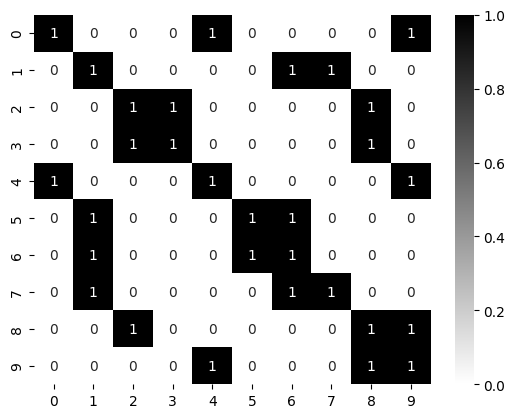

In [20]:
sns.heatmap(data=nnbrs.kneighbors_graph(X).toarray(),annot=True,cmap='binary')
# This is the matrix of the points and their respective nearest neighbors.
# For each row the neighbors are the columns excluding itself or vice versa
plt.show()